# Day 26 — 基本面分析入门：PE / PB / ROE

技术面告诉你「什么时候买卖」，基本面告诉你「买的是好公司还是烂公司」。

今天学习三个最核心的基本面指标。

## 一、PE（市盈率）

**公式**：PE = 股价 ÷ 每股收益

**含义**：你花多少钱买下公司 1 元钱的利润。

findfont: Failed to find font weight normal, now using 300.


findfont: Failed to find font weight normal, now using 300.


findfont: Failed to find font weight bold, now using 600.


findfont: Failed to find font weight normal, now using 300.


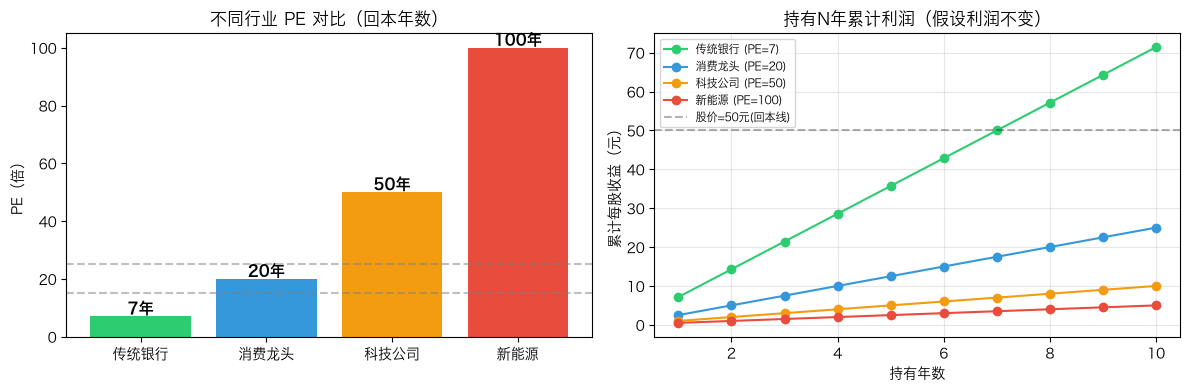

✅ PE越低，回本越快。但高PE背后可能是高增长预期。


In [1]:
# PE 演示：不同回本年数的直观对比
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Hiragino Sans GB']
plt.rcParams['axes.unicode_minus'] = False

# 假设四种公司的PE
stocks = ['传统银行', '消费龙头', '科技公司', '新能源']
pe = [7, 20, 50, 100]
price = [50, 50, 50, 50]  # 假设股价相同
eps = [p/e for p, e in zip(price, pe)]  # 反推每股收益

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 图1: PE柱状图（回本年数）
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
bars = axes[0].bar(stocks, pe, color=colors)
axes[0].axhline(y=15, color='gray', linestyle='--', alpha=0.5, label='合理区间(15-25)')
axes[0].axhline(y=25, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('不同行业 PE 对比（回本年数）')
axes[0].set_ylabel('PE（倍）')
for bar, v in zip(bars, pe):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{v}年', ha='center', fontsize=11, fontweight='bold')

# 图2: 每年利润对比
years = list(range(1, 11))
for i, (name, e) in enumerate(zip(stocks, eps)):
    cumulative = [e * y for y in years]
    axes[1].plot(years, cumulative, marker='o', label=f'{name} (PE={pe[i]})', color=colors[i])
axes[1].axhline(y=50, color='black', linestyle='--', alpha=0.3, label='股价=50元(回本线)')
axes[1].set_title('持有N年累计利润（假设利润不变）')
axes[1].set_xlabel('持有年数')
axes[1].set_ylabel('累计每股收益（元）')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/macbookpro/Desktop/股/day26/PE回本对比.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ PE越低，回本越快。但高PE背后可能是高增长预期。')

## 二、PB（市净率）

**公式**：PB = 股价 ÷ 每股净资产

**含义**：股价是公司净资产（清算价值）的多少倍。
PB<1 = 破净，股价比公司清算价值还低。

findfont: Failed to find font weight bold, now using 600.


findfont: Failed to find font weight normal, now using 300.


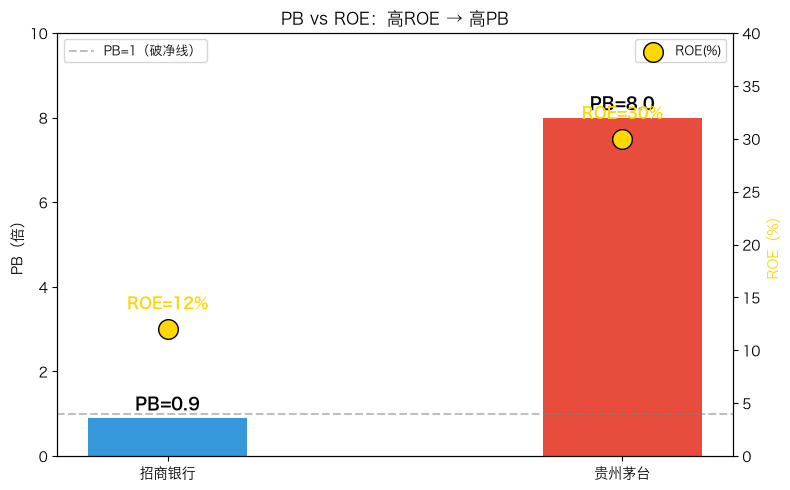

✅ ROE决定PB。茅台ROE高→市场给高PB；招商银行ROE低→PB接近1。


In [2]:
# PB 演示：用真实数据对比招商银行和茅台

fig, ax = plt.subplots(figsize=(8, 5))

# 近似真实数据
companies = ['招商银行', '贵州茅台']
pb_values = [0.9, 8.0]
roe_values = [12, 30]

# 双Y轴
ax2 = ax.twinx()

bars = ax.bar(companies, pb_values, color=['#3498db', '#e74c3c'], width=0.35)
ax.set_ylabel('PB（倍）', color='black')
ax.set_ylim(0, 10)

# ROE 散点叠加
ax2.scatter(companies, roe_values, s=200, c='gold', edgecolors='black', zorder=5, label='ROE(%)')
ax2.set_ylabel('ROE（%）', color='gold')
ax2.set_ylim(0, 40)

for bar, v in zip(bars, pb_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'PB={v}', ha='center', fontsize=12, fontweight='bold')
for i, (c, r) in enumerate(zip(companies, roe_values)):
    ax2.annotate(f'ROE={r}%', (c, r), textcoords="offset points", xytext=(0, 15), ha='center', fontsize=11, color='gold', fontweight='bold')

ax.set_title('PB vs ROE：高ROE → 高PB')
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='PB=1（破净线）')
ax.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('/Users/macbookpro/Desktop/股/day26/PB_ROE对比.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ ROE决定PB。茅台ROE高→市场给高PB；招商银行ROE低→PB接近1。')

## 三、ROE（净资产收益率）

**公式**：ROE = 净利润 ÷ 净资产 × 100%

**含义**：公司用股东的钱，一年能赚多少回来。
ROE 是 PE 和 PB 之间的桥梁。

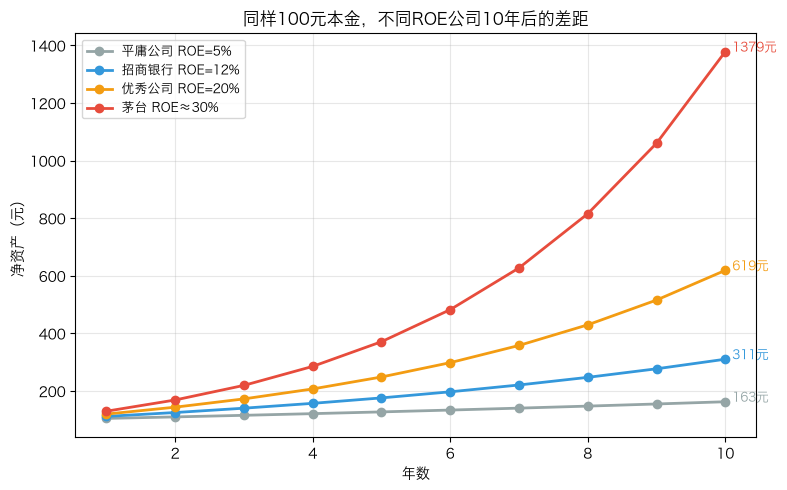

✅ ROE差5倍，10年后资产差几倍。高ROE是复利发动机。


In [3]:
# ROE 的意义演示：同样投100元，不同ROE的差距

years = list(range(1, 11))
initial = 100

fig, ax = plt.subplots(figsize=(8, 5))

for roe, label, color in [(5, '平庸公司 ROE=5%', '#95a5a6'),
                            (12, '招商银行 ROE=12%', '#3498db'),
                            (20, '优秀公司 ROE=20%', '#f39c12'),
                            (30, '茅台 ROE≈30%', '#e74c3c')]:
    values = [initial * (1 + roe/100)**y for y in years]
    ax.plot(years, values, marker='o', linewidth=2, label=label, color=color)
    ax.annotate(f'{values[-1]:.0f}元', (10, values[-1]), textcoords="offset points", xytext=(5, 0), fontsize=9, color=color)

ax.set_title('同样100元本金，不同ROE公司10年后的差距')
ax.set_xlabel('年数')
ax.set_ylabel('净资产（元）')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/macbookpro/Desktop/股/day26/ROE复利效应.png', dpi=120, bbox_inches='tight')
plt.show()

print('✅ ROE差5倍，10年后资产差几倍。高ROE是复利发动机。')

## 四、三角关系总结

PE、PB、ROE 互相勾连：
- **ROE** = 净利润 ÷ 净资产（赚钱效率）
- **PB** = 股价 ÷ 净资产（市场给的溢价）
- **PE** = 股价 ÷ 净利润 = PB ÷ ROE

核心规律：**长期来看，ROE 越高的公司，市场给的 PB 越高。**

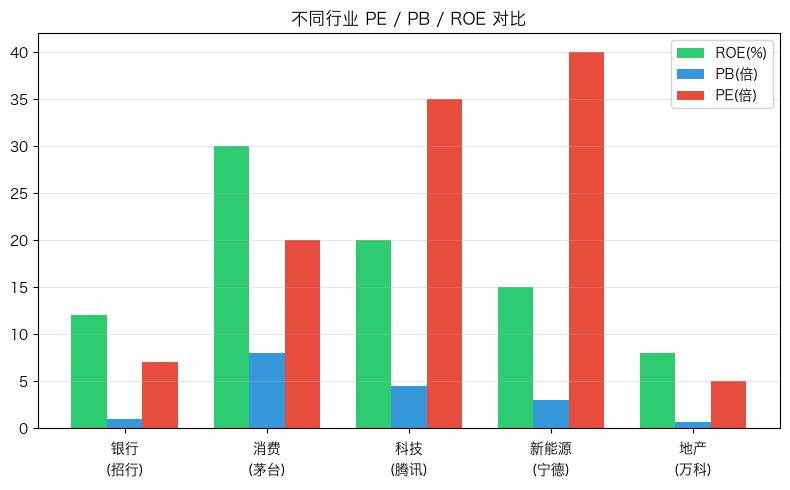

✅ 同一行业内部对比才有效。银行和科技比PE没意义。


In [4]:
# 三角关系可视化
fig, ax = plt.subplots(figsize=(8, 5))

# 模拟不同行业的数据
industries = ['银行\n(招行)', '消费\n(茅台)', '科技\n(腾讯)', '新能源\n(宁德)', '地产\n(万科)']
roe_data = [12, 30, 20, 15, 8]
pb_data = [0.9, 8.0, 4.5, 3.0, 0.6]
pe_data = [7, 20, 35, 40, 5]

x = range(len(industries))
width = 0.25

bars1 = ax.bar([i - width for i in x], roe_data, width, label='ROE(%)', color='#2ecc71')
bars2 = ax.bar([i for i in x], pb_data, width, label='PB(倍)', color='#3498db')
bars3 = ax.bar([i + width for i in x], pe_data, width, label='PE(倍)', color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(industries)
ax.set_title('不同行业 PE / PB / ROE 对比')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/Users/macbookpro/Desktop/股/day26/三角关系.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ 同一行业内部对比才有效。银行和科技比PE没意义。')

## 总结

| 指标 | 问的问题 | 公式 | 看什么 |
|------|----------|------|--------|
| PE | 多少年回本？ | 股价÷每股收益 | 市场对公司利润的定价 |
| PB | 股价比资产贵多少？ | 股价÷每股净资产 | 市场对净资产的溢价程度 |
| ROE | 赚钱效率高吗？ | 净利润÷净资产 | 管理层用股东钱的能力 |

**技术面 + 基本面 = 完整的交易决策框架。**